# Hypothesis Test - T-Test

We will use a dataset on diabetes and life style to illustrate various types of Hypothesis Tests involving a T Statistic. 

In [1]:
import pandas as pd
import os

diabetes_file_path = os.path.join(os.getcwd(), 'datasets', 'Diabetes_and_LifeStyle_Dataset.csv')
diabetes_df = pd.read_csv(diabetes_file_path)

In [2]:
diabetes_df

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97292,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
97293,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
97294,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
97295,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


# 1-Pop T-Test Example

Assumptions: 
- Dependent Variable is continuous
- Observation data is independent 
- Sample data is approximately normal OR n > 30

## Research Question Example
People with diabetes have less than 2 hours of physical activity per week. 

## Check Assumptions

- The dependent variable is physical_activity_per_week, which is measured in minutes (a continous measure of time) and presented as a float. 
- Observation data is of individual people and thus assumed to be independent.
- Our sample size is 97,297 and so is above n > 30. We can still check if the sample is normally distributed or has extreme outliers.

<Axes: xlabel='physical_activity_minutes_per_week', ylabel='Count'>

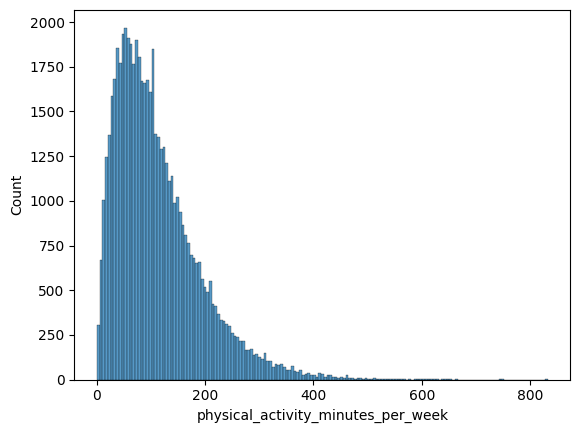

In [14]:
import seaborn as sns

diabetes_only_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 1].copy()
sns.histplot(data=diabetes_only_df, x='physical_activity_minutes_per_week')

## Hypotheses

$H_0: \mu = 120$ minutes

$H_a: \mu < 120$ minutes

## P-Value

In [15]:
from scipy import stats

activity_diabetes_only_series = diabetes_only_df['physical_activity_minutes_per_week']
results = stats.ttest_1samp(activity_diabetes_only_series, popmean=120)
print(f'P-value: {results.pvalue}')

P-value: 2.175850972836851e-127


## Power and Effect Size

Since we already have a sample, we know 'nobs' (number of observations). We can choose power and calculate effect size OR we can choose effect size and calculate power. We commonly choose power to be 0.8 or greater and calculate effect size. 

In [23]:
from statsmodels.stats.power import TTestPower

effect_size_1_pop_t = TTestPower().solve_power(
    effect_size=None, 
    nobs=len(activity_diabetes_only_series), 
    alpha=0.05,
    power=0.9,
    alternative='smaller'
)
print(f'Effect size: {round(effect_size_1_pop_t, 3)}')

Effect size: 0.157


## Final Interpretation

We conducted a hypothesis test to determine if there is statistically significant evidence that all people with diabetes have less than 2 hours of physical activity per week. With a p-value of 2.18e-127, our sample suggests we do have statistically significant evidence that all people with diabetes have less than 2 hours of physical activity per week. However, with an effect size of 0.157, we observe a small effect and thus the true average of physical activity of people with diabetes is likely less than but close to 2 hours per week. 

# 2-Pop T-Test Example

Assumptions: 
- Dependent Variable is continuous
- Observation data is independent 
- Sample data is approximately normal OR n > 30
- Variance is equal between populations OR Variance is not equal between populations (Welch T-Test)

## Research Question

There is no difference in average BMI between people who do and do not have diabetes. 

## Check Assumptions

- The dependent variable is Body Mass Index (BMI), which is measured in kilograms per square meter (continuous) and presented as a float. 
- Observation data is of individual people and thus assumed to be independent.
- Our sample size is 97,297 and so is above n > 30. We can still check if the sample is normally distributed or has extreme outliers.
- We don't know that the population variance are the same, so let's examine the samples and see if we they might be. Otherwise we will assume the population variances are different.

In [41]:
diabetes_only_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 1].copy()
bmi_yes_diabetes_series = diabetes_only_df['bmi']
bmi_yes_variance = bmi_yes_diabetes_series.var()
print(f'Diabetes sample variance: {round(bmi_yes_variance, 3)}')

no_diabetes_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 0].copy()
bmi_no_diabetes_series = no_diabetes_df['bmi']
bmi_no_variance = bmi_no_diabetes_series.var()
print(f'No diabetes sample variance: {round(bmi_no_variance, 3)}')


Diabetes sample variance: 12.814
No diabetes sample variance: 12.667


These are fairly close, so we can assume the population variances are the same. Interested students can run the hypothesis test without this assumption to see what changes.

We can look at the distributions to see why variance might be assumed to be the same and see if the data is normally distributed.

<Axes: xlabel='bmi', ylabel='Count'>

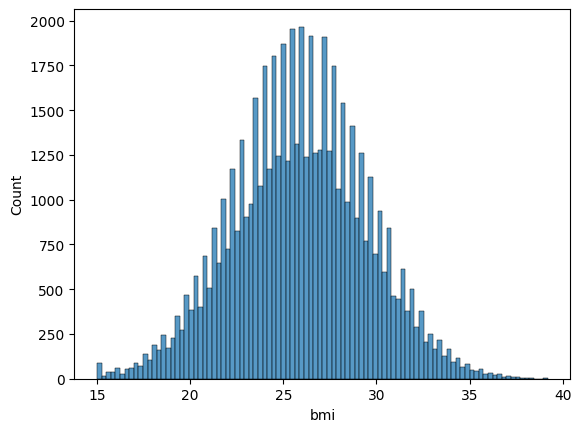

In [ ]:
sns.histplot(data=diabetes_only_df, x='bmi')

<Axes: xlabel='bmi', ylabel='Count'>

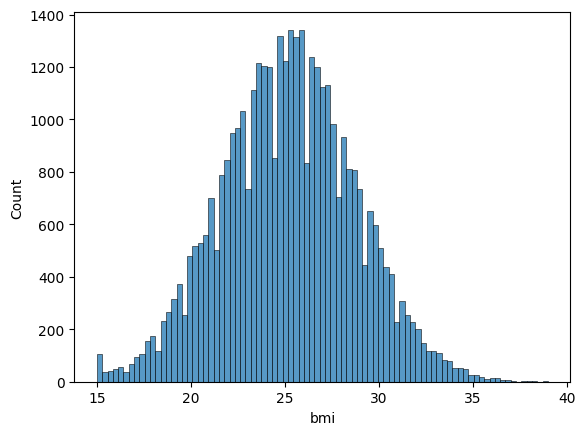

In [ ]:
sns.histplot(data=no_diabetes_df, x='bmi')

## P-Value

In [ ]:
results_2pop = stats.ttest_ind(
    bmi_yes_diabetes_series,
    bmi_no_diabetes_series, 
    equal_var=True, # This is true by default
    alternative='two-sided', # This is two-sided by default
)
print(f'P-value: {results_2pop.pvalue}')

P-value: 7.272802236405973e-203


## Power and Effect Size

In [47]:
from statsmodels.stats.power import TTestIndPower

diabetes_nobs1 = len(bmi_yes_diabetes_series)
diabetes_nobs2 = len(bmi_no_diabetes_series)
diabetes_ratio = diabetes_nobs2/diabetes_nobs1

effect_size_2_pop_t = TTestIndPower().solve_power(
    effect_size=None, 
    nobs1=diabetes_nobs1, 
    alpha=0.05,
    power=0.9,
    ratio=diabetes_ratio,
    alternative='two-sided'
)
print(f'Effect size: {round(effect_size_2_pop_t, 3)}')

Effect size: 0.021


## Final Interpretation

We conducted a hypothesis test to determine if there is statistically significant evidence that there is a difference in average BMI between people who do and do not have diabetes. With a p-value of 7.27e-203, our sample suggests we do have statistically significant evidence that there is a difference in average BMI between people who do and do not have diabetes. However, with an effect size of 0.021, we observe a very small effect and thus the true average BMI between people who do and do not have diabetes is different but very small. 

*Notice: Since we conducted a 2-tail hypothesis test, we cannot say one population's average BMI is smaller than the other. You would need to conduct the 1-tail hypothesis test to confirm which is likely smaller.*